- Se construye un modelo de costos para un proyecto genérico compuesto por cinco partidas principales. El modelo determinístico suma los costos base y posteriormente se introduce incertidumbre mediante distribuciones de probabilidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
items = {"Materiales": 25000,
         "Mano_de_obra": 18000,
         "Transporte": 3500,
        "Permisos": 2000,
        "Imprevistos": 4000}

costo_deterministico = sum(items.values())
costo_deterministico

52500

In [ ]:
params_A = {"Materiales": ("normal", 25000, 3000),
            "Mano_de_obra": ("normal", 18000, 2500),
        "Transporte": ("triangular", 2500, 3500, 5000),
        "Permisos": ("triangular", 1500, 2000, 3000),
        "Imprevistos": ("triangular", 2000, 4000, 9000)}

In [4]:
def sample_variable(dist_info):
    dist = dist_info[0]

    if dist == "normal":
        mu, sigma = dist_info[1], dist_info[2]
        x = np.random.normal(mu, sigma)
        return max(x, 0)  # para evitar costos negativos

    elif dist == "triangular":
        a, c, b = dist_info[1], dist_info[2], dist_info[3]
        return np.random.triangular(a, c, b)

    else:
        raise ValueError("Distribución no soportada")

In [5]:
n_iter = 5000
resultados_A = []

for i in range(n_iter):
    costo_total = 0
    
    for item, dist_info in params_A.items():
        costo_total += sample_variable(dist_info)
    
    resultados_A.append(costo_total)

resultados_A = np.array(resultados_A)
resultados_A[:5], len(resultados_A)

(array([53528.92740093, 54524.38629438, 61069.40403812, 43479.8973616 ,
        55311.8088973 ]),
 5000)

In [6]:
media = resultados_A.mean()
mediana = np.median(resultados_A)
p05 = np.percentile(resultados_A, 5)
p95 = np.percentile(resultados_A, 95)

media, mediana, p05, p95

(np.float64(53757.777486569044),
 np.float64(53686.66922594044),
 np.float64(46917.45616319371),
 np.float64(60483.956820065585))

In [7]:
presupuesto = costo_deterministico
prob_sobre = (resultados_A > presupuesto).mean()
prob_sobre

np.float64(0.618)

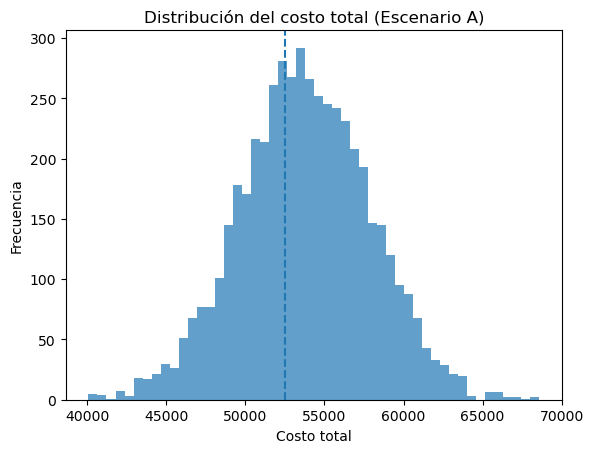

In [8]:
plt.hist(resultados_A, bins=50, alpha=0.7)
plt.axvline(presupuesto, linestyle="--")
plt.title("Distribución del costo total (Escenario A)")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.show()

In [9]:
#Escenario B cambiando distribuciones
params_B = {"Materiales": ("triangular", 21000, 25000, 32000),"Mano_de_obra": ("triangular", 14000, 18000, 24000),
    "Transporte": ("triangular", 2500, 3500, 5000),"Permisos": ("triangular", 1500, 2000, 3000),
    "Imprevistos": ("triangular", 2000, 4000, 9000)}

In [10]:
resultados_B = []

for i in range(n_iter):
    costo_total = 0
    for item, dist_info in params_B.items():
        costo_total += sample_variable(dist_info)
    resultados_B.append(costo_total)

resultados_B = np.array(resultados_B)

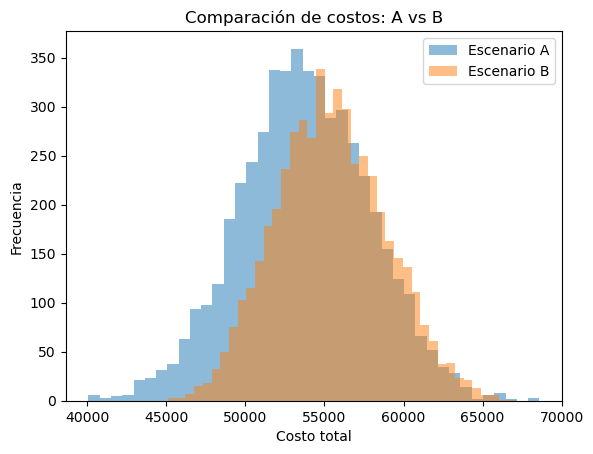

In [11]:
plt.hist(resultados_A, bins=40, alpha=0.5, label="Escenario A")
plt.hist(resultados_B, bins=40, alpha=0.5, label="Escenario B")
plt.legend()
plt.title("Comparación de costos: A vs B")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.show()

In [12]:
#Sensibilidad
n_iter = 5000
sim_data = []

for i in range(n_iter):
    fila = {}
    total = 0
    
    for item, dist_info in params_A.items():
        val = sample_variable(dist_info)
        fila[item] = val
        total += val
    
    fila["Total"] = total
    sim_data.append(fila)

sim_df = pd.DataFrame(sim_data)
sim_df.head()

,Materiales,Mano_de_obra,Transporte,Permisos,Imprevistos,Total
0,32112.861027,16716.031967,3362.377428,1991.430185,5024.292294,59206.992902
1,20227.053155,18351.409574,3762.406223,1883.837820,5050.962074,49275.668845
2,28104.048499,13666.294907,3602.836019,2657.857350,4607.839456,52638.876232
3,25241.698719,17605.172232,3369.512062,2204.934088,4445.998361,52867.315462
4,21648.103461,17707.790019,3458.767367,2101.456582,5327.506018,50243.623447


In [13]:
sens = sim_df.corr(numeric_only=True)["Total"].sort_values(ascending=False)
sens

Total           1.000000
Materiales      0.715452
Mano_de_obra    0.587039
Imprevistos     0.362700
Transporte      0.128870
Permisos        0.068769
Name: Total, dtype: float64

### Conclusión

- En este trabajo se desarrolló un modelo de costos para un proyecto utilizando simulación Monte Carlo. Primero se calculó un presupuesto determinístico, que representa el costo esperado si todo saliera exactamente como se planeó. Sin embargo, este enfoque no considera la incertidumbre que existe en la vida real.

- Para resolver esto, se asignaron distribuciones de probabilidad a cada componente del costo, lo que permitió representar la variabilidad natural de los precios. A partir de estas distribuciones se realizaron 5000 simulaciones, generando miles de posibles escenarios del costo total del proyecto.

- Los resultados muestran que el costo del proyecto no es un valor único, sino una distribución de posibles resultados. Esto permite estimar no solo el costo promedio, sino también el riesgo de exceder el presupuesto y los rangos en los que podría ubicarse el costo en escenarios desfavorables.

- Al comparar dos tipos de distribuciones, se observó que los supuestos sobre la incertidumbre influyen directamente en el nivel de riesgo. Además, el análisis de sensibilidad permitió identificar qué variables tienen mayor impacto en el costo final, lo que ayuda a enfocar los esfuerzos de control en los factores más importantes.

- En conclusión, la simulación Monte Carlo es una herramienta útil para evaluar costos bajo incertidumbre y apoyar una mejor toma de decisiones.